In [1]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px



pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
wine = fetch_ucirepo(id=186)

In [3]:
# wine

In [4]:
# type(wine)
# # 


In [5]:
wine_df = pd.DataFrame.from_dict(wine.data.original)

wine_df.to_csv('Wine.csv')

wine_df.head(5)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,7.40,0.70,0.00,1.90,0.08,11.00,34.00,1.00,3.51,0.56,9.40,5,red
1,7.80,0.88,0.00,2.60,0.10,25.00,67.00,1.00,3.20,0.68,9.80,5,red
2,7.80,0.76,0.04,2.30,0.09,15.00,54.00,1.00,3.26,0.65,9.80,5,red
3,11.20,0.28,0.56,1.90,0.07,17.00,60.00,1.00,3.16,0.58,9.80,6,red
4,7.40,0.70,0.00,1.90,0.08,11.00,34.00,1.00,3.51,0.56,9.40,5,red


In [6]:
wine_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  color                 6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 688.6 KB


In [7]:
(wine_df_summary := wine_df.describe())

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00
mean,7.22,0.34,0.32,5.44,0.06,30.53,115.74,0.99,3.22,0.53,10.49,5.82
std,1.30,0.16,0.15,4.76,0.04,17.75,56.52,0.00,0.16,0.15,1.19,0.87
min,3.80,0.08,0.00,0.60,0.01,1.00,6.00,0.99,2.72,0.22,8.00,3.00
25%,6.40,0.23,0.25,1.80,0.04,17.00,77.00,0.99,3.11,0.43,9.50,5.00
50%,7.00,0.29,0.31,3.00,0.05,29.00,118.00,0.99,3.21,0.51,10.30,6.00
75%,7.70,0.40,0.39,8.10,0.07,41.00,156.00,1.00,3.32,0.60,11.30,6.00
max,15.90,1.58,1.66,65.80,0.61,289.00,440.00,1.04,4.01,2.00,14.90,9.00


### Inspect Wine dataframe based on Wine color

In [8]:
print(f'The \'color\' column of the wine dataframe contains {len(wine_colors:=list(wine_df['color'].unique()))} colors : {wine_colors}')

The 'color' column of the wine dataframe contains 2 colors : ['red', 'white']


#### Inspection of the Red wine collection

In [9]:
red_wine_df = wine_df.query("color=='red'")

display(red_wine_df.head())

print(f'Red wine dataframe has the shape {red_wine_df.shape}')

print(f'''   
Empty Values ?
 The Red wine collection has {sum(red_wine_df.isna().sum())} missing values \n
Duplicate Values ? \n
    Total Duplicates:
      The Red wine collection has \'{(num_dup := red_wine_df.duplicated().sum())}\' duplicate values out of \'{(total_obs := red_wine_df. shape[0])}\' observations
      
    Distinct Duplicate Pattern:
      Exactly {((red_wine_duplicated := red_wine_df[red_wine_df.duplicated].value_counts().to_frame()['count'].apply(lambda x: x + 1)) > 1).sum()} distinct rows appear more than once in the Red wine collection
  
The most occuring entry appears {max(red_wine_duplicated)} times
      ''')

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,7.40,0.70,0.00,1.90,0.08,11.00,34.00,1.00,3.51,0.56,9.40,5,red
1,7.80,0.88,0.00,2.60,0.10,25.00,67.00,1.00,3.20,0.68,9.80,5,red
2,7.80,0.76,0.04,2.30,0.09,15.00,54.00,1.00,3.26,0.65,9.80,5,red
3,11.20,0.28,0.56,1.90,0.07,17.00,60.00,1.00,3.16,0.58,9.80,6,red
4,7.40,0.70,0.00,1.90,0.08,11.00,34.00,1.00,3.51,0.56,9.40,5,red


Red wine dataframe has the shape (1599, 13)
   
Empty Values ?
 The Red wine collection has 0 missing values 

Duplicate Values ? 

    Total Duplicates:
      The Red wine collection has '240' duplicate values out of '1599' observations

    Distinct Duplicate Pattern:
      Exactly 220 distinct rows appear more than once in the Red wine collection

The most occuring entry appears 4 times
      


#### Inspection of the White wine collection 

In [10]:
white_wine_df = wine_df.query("color=='white'")

display(white_wine_df.head())

print(f'White wine dataframe has the shape {white_wine_df.shape}')

print(f'''   
Empty Values ?
 The White wine collection has {sum(white_wine_df.isna().sum())} missing values \n
Duplicate Values ? \n
    Total Duplicates:
      The White wine collection has \'{(num_dup := white_wine_df.duplicated().sum())}\' duplicate values out of \'{(total_obs := white_wine_df. shape[0])}\' observations
      
    Distinct Duplicate Pattern:
      Exactly {((white_wine_duplicated := white_wine_df[white_wine_df.duplicated].value_counts().to_frame()['count'].apply(lambda x: x + 1)) > 1).sum()} distinct rows appear more than once in the white wine collection
  
The most occuring entry appears {max(white_wine_duplicated)} times
      ''')

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
1599,7.00,0.27,0.36,20.70,0.04,45.00,170.00,1.00,3.00,0.45,8.80,6,white
1600,6.30,0.30,0.34,1.60,0.05,14.00,132.00,0.99,3.30,0.49,9.50,6,white
1601,8.10,0.28,0.40,6.90,0.05,30.00,97.00,1.00,3.26,0.44,10.10,6,white
1602,7.20,0.23,0.32,8.50,0.06,47.00,186.00,1.00,3.19,0.40,9.90,6,white
1603,7.20,0.23,0.32,8.50,0.06,47.00,186.00,1.00,3.19,0.40,9.90,6,white


White wine dataframe has the shape (4898, 13)
   
Empty Values ?
 The White wine collection has 0 missing values 

Duplicate Values ? 

    Total Duplicates:
      The White wine collection has '937' duplicate values out of '4898' observations

    Distinct Duplicate Pattern:
      Exactly 772 distinct rows appear more than once in the white wine collection

The most occuring entry appears 8 times
      


### Wine Dataframe statistical exploration

In [11]:
diff = wine_df_summary.loc['max'] - wine_df_summary.loc['75%']
condition = diff > wine_df_summary.loc['mean']
sus_columns = wine_df_summary.columns[condition].tolist()

sus_columns

['fixed_acidity',
 'volatile_acidity',
 'citric_acid',
 'residual_sugar',
 'chlorides',
 'free_sulfur_dioxide',
 'total_sulfur_dioxide',
 'sulphates']

In [12]:
# for item, value in dict(wine_df_summary.loc['max']).items():
#     for item, upper_limit in dict(wine_df_summary.loc['75%']).items():
#         for item, mean_value in dict(wine_df_summary.loc['mean']).items():
#             if (value - upper_limit > mean_value):
#                 sus_columns.append(item)

In [13]:
# Q3 = wine_df_summary.loc['75%', 'residual_sugar']
# Q1 = wine_df_summary.loc['25%', 'residual_sugar']

# IQR = Q3 - Q1


# print(f'Upper Limit: { Q3 + (1.5 * IQR)} \nLower Limit: { Q1 - (1.5 * IQR)}')


In [14]:
for col in wine_df_summary.columns:
    Q1 = wine_df_summary.loc['25%', col]
    Q3 = wine_df_summary.loc['75%', col]
    
    IQR = Q3 - Q1
    
    wine_df_summary.loc['lower_fence', col] = Q1 - (1.5 * IQR)
    wine_df_summary.loc['upper_fence', col] = Q3 + (1.5 * IQR)
    
    bounded_obs = ~ (
        
        wine_df[col].between(
            
            wine_df_summary.loc['lower_fence', col], 
            wine_df_summary.loc['upper_fence', col]
            
            )
                     )
    
    wine_df_summary.loc['outliers', col] = bounded_obs.sum()
    
    

In [15]:
wine_df_summary

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00
mean,7.22,0.34,0.32,5.44,0.06,30.53,115.74,0.99,3.22,0.53,10.49,5.82
std,1.30,0.16,0.15,4.76,0.04,17.75,56.52,0.00,0.16,0.15,1.19,0.87
min,3.80,0.08,0.00,0.60,0.01,1.00,6.00,0.99,2.72,0.22,8.00,3.00
25%,6.40,0.23,0.25,1.80,0.04,17.00,77.00,0.99,3.11,0.43,9.50,5.00
50%,7.00,0.29,0.31,3.00,0.05,29.00,118.00,0.99,3.21,0.51,10.30,6.00
75%,7.70,0.40,0.39,8.10,0.07,41.00,156.00,1.00,3.32,0.60,11.30,6.00
max,15.90,1.58,1.66,65.80,0.61,289.00,440.00,1.04,4.01,2.00,14.90,9.00
lower_fence,4.45,-0.02,0.04,-7.65,-0.00,-19.00,-41.50,0.99,2.79,0.17,6.80,3.50
upper_fence,9.65,0.66,0.60,17.55,0.11,77.00,274.50,1.00,3.63,0.85,14.00,7.50


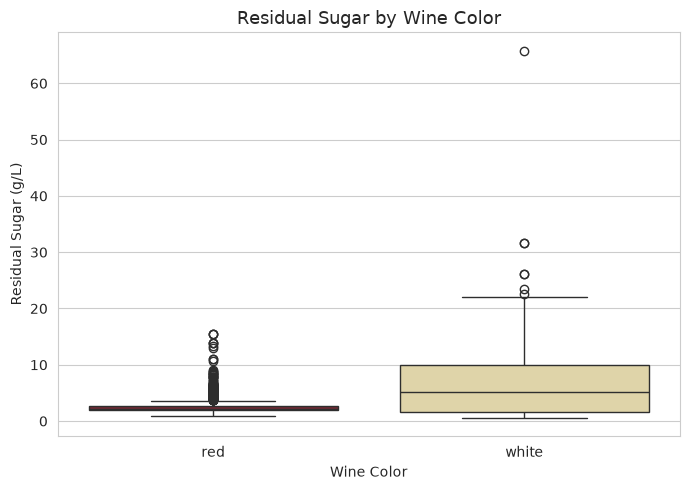

In [16]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=wine_df,
    x='color',
    y='residual_sugar',
    hue='color',
    palette={'red': '#7b1e2b', 'white': '#e8d9a0'},
    legend=False,
    ax=ax
)

ax.set_title('Residual Sugar by Wine Color', fontsize=13)
ax.set_xlabel('Wine Color')
ax.set_ylabel('Residual Sugar (g/L)')

plt.tight_layout()

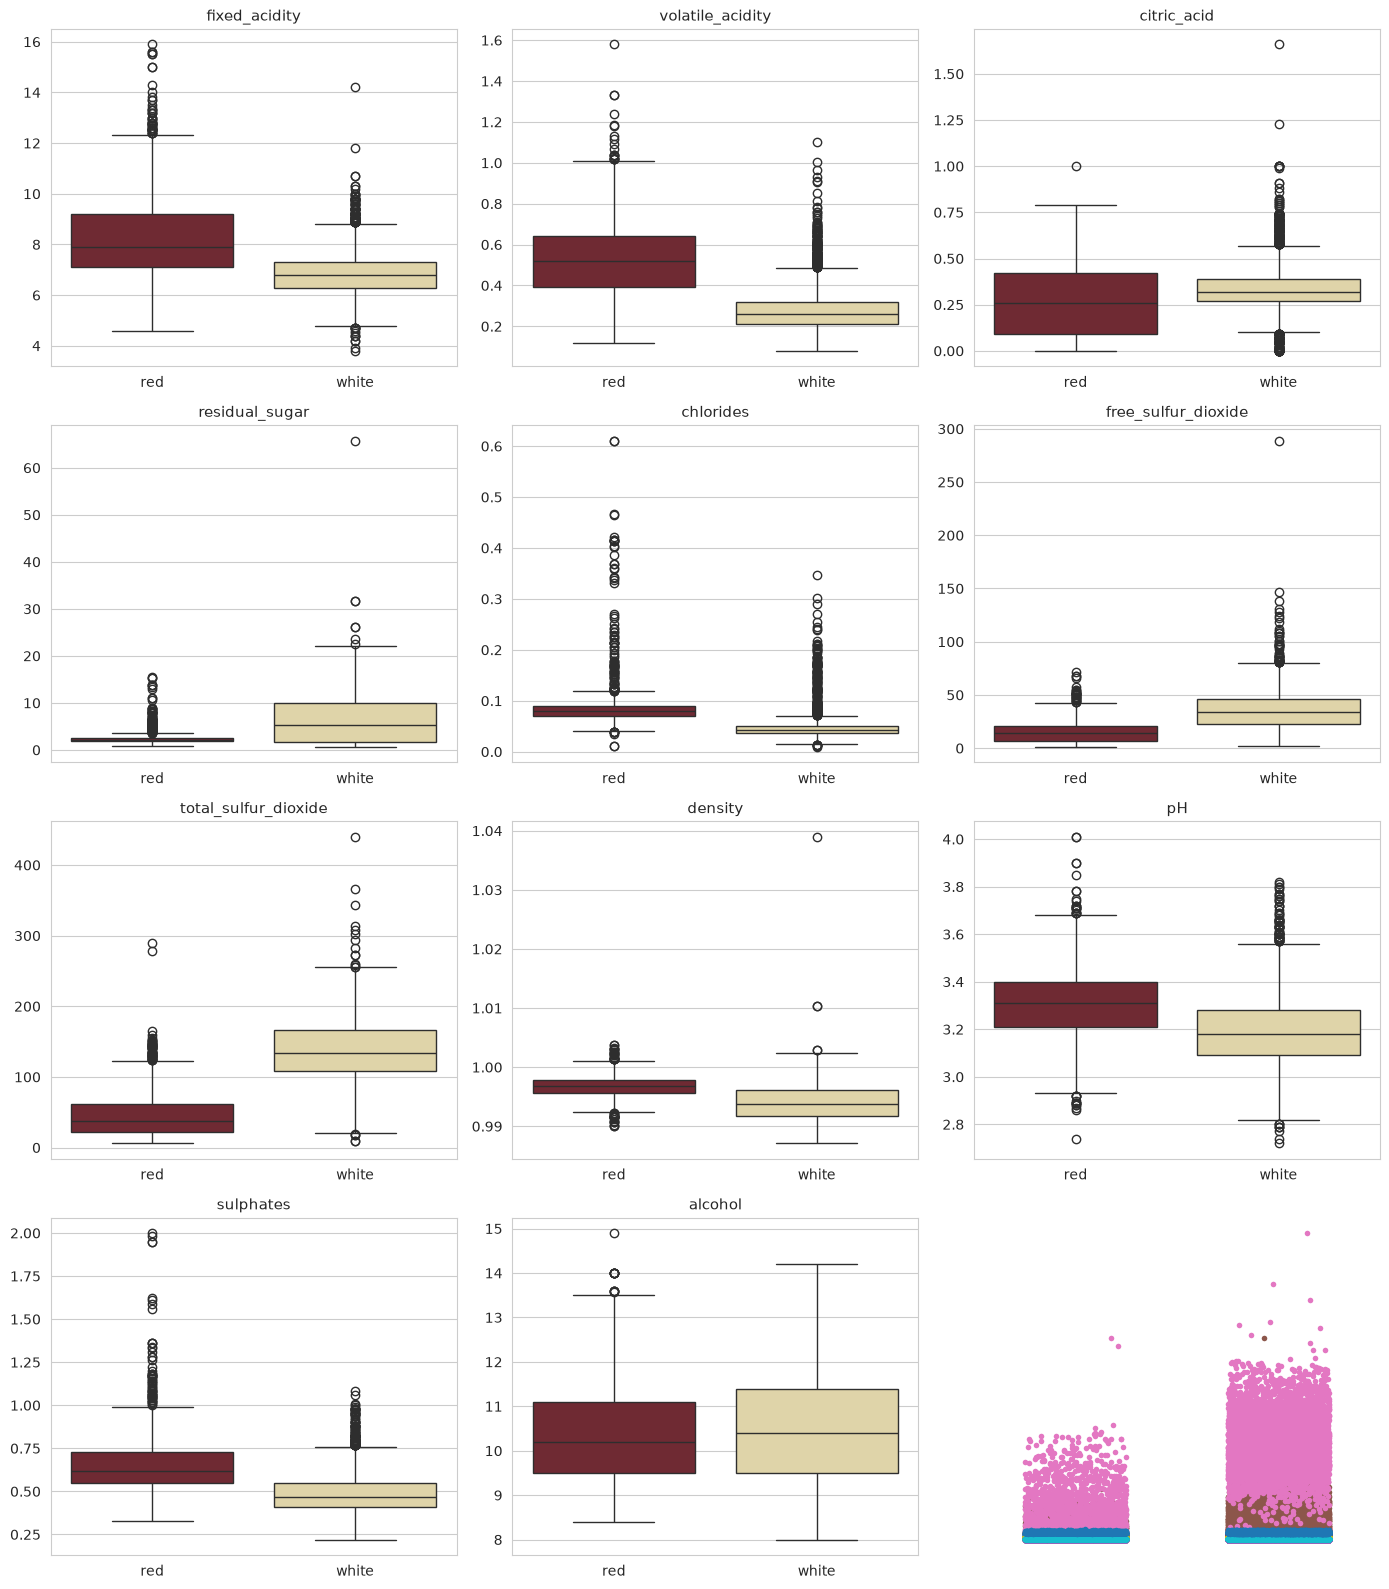

In [ ]:
physicochemical_vars = [
    'fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
    'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide',
    'density', 'pH', 'sulphates', 'alcohol'
]

sns.set_style("whitegrid")
fig, axes = plt.subplots(4, 3, figsize=(14, 16))
axes = axes.flatten()

palette = {'red': '#7b1e2b', 'white': '#e8d9a0'}

for i, col in enumerate(physicochemical_vars):
    sns.boxplot(
        data=wine_df, x='color', y=col, hue='color',
        palette=palette, legend=False, ax=axes[i]
    )
    # sns.swarmplot(
    #     data=wine_df, x='color', y=col, hue='color'
    # )
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# hide the unused 12th subplot slot
axes[-1].axis('off')

plt.tight_layout()